# Exploratory Data Analysis and Baseline Model Evaluation

### Setup and Dependencies

In [49]:
%load_ext autoreload
%autoreload 2

import sys
import warnings
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

DATA_DIR = PROJECT_ROOT / 'data' / 'raw'

warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader

from src.data.data_loader import load_cmapss_data, StreamingCMAPSSDataset
from src.models.baseline import evaluate_baseline

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Data Loading and Preprocessing

In [50]:
train_path = str(DATA_DIR / 'train_FD001.txt')
df_train = load_cmapss_data(train_path)

print(f"Dataset shape: {df_train.shape}")
display(df_train.head())

Dataset shape: (20631, 27)


,unit_nr,time_cycles,setting_1,setting_2,setting_3,s_1,s_2,s_3,s_4,s_5,...,s_13,s_14,s_15,s_16,s_17,s_18,s_19,s_20,s_21,RUL
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,191
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,190
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,189
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,188
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,187


### Streaming Data Simulation

In [51]:
sensor_features = [f's_{i}' for i in range(1, 22)]
train_dataset = StreamingCMAPSSDataset(df_train, sensor_features)

stream_loader = DataLoader(train_dataset, batch_size=32, shuffle=False)
X_batch, y_batch = next(iter(stream_loader))

print(f"Feature batch shape (X): {X_batch.shape}")
print(f"Target batch shape (y):  {y_batch.shape}")

Feature batch shape (X): torch.Size([32, 21])
Target batch shape (y):  torch.Size([32, 1])


### Sensor Variance Analysis

Constant sensors to be aware of (Zero Variance): ['s_1', 's_10', 's_18', 's_19']


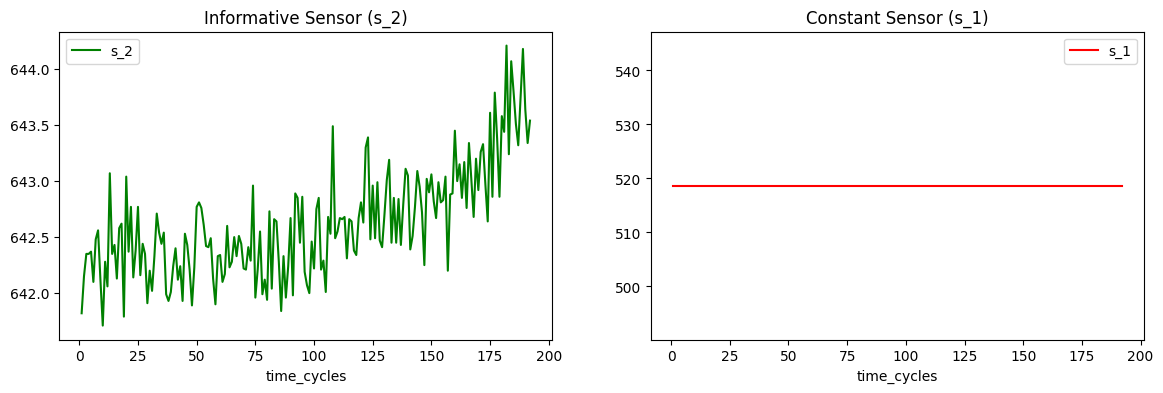

In [52]:
# Check sensor variance to identify non-informative (constant) features
sensor_columns = [f's_{i}' for i in range(1, 21)]
variance_check = df_train[sensor_columns].std()

# Identify sensors with zero variance
constant_sensors = variance_check[variance_check == 0].index.tolist()

print(f"Constant sensors to be aware of (Zero Variance): {constant_sensors}")

# Plot one changing sensor vs one constant sensor for visual proof
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
df_train[df_train['unit_nr'] == 1].plot(x='time_cycles', y='s_2', ax=ax[0], color='green', title='Informative Sensor (s_2)')
df_train[df_train['unit_nr'] == 1].plot(x='time_cycles', y='s_1', ax=ax[1], color='red', title='Constant Sensor (s_1)')
plt.show()

### Baseline Evaluation & Trajectory Plot


--- BASELINE BENCHMARK RESULTS (TEST SET) ---
RMSE: 45.95 cycles
MAE:  34.50 cycles



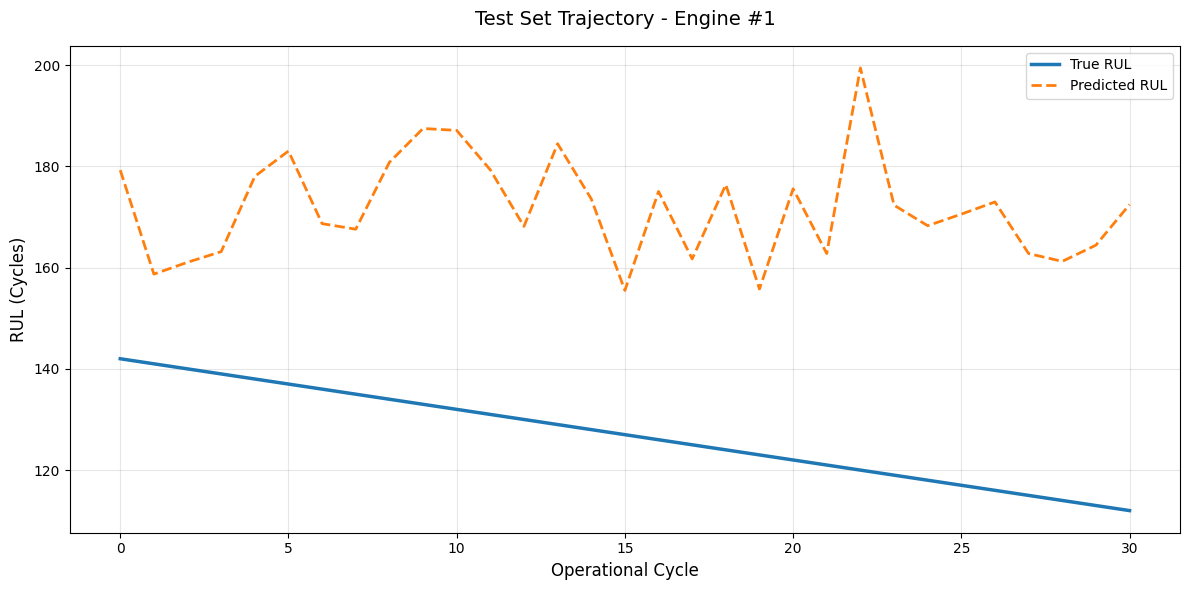

In [53]:
rf_baseline, scaler = evaluate_baseline()

test_path = str(DATA_DIR / 'test_FD001.txt')
rul_path = str(DATA_DIR / 'RUL_FD001.txt')
df_test = load_cmapss_data(test_path, rul_path)

def plot_test_degradation(df, model, scaler, engine_id=1, features=sensor_features):
    engine_data = df[df['unit_nr'] == engine_id]
    
    # Scale features and extract targets
    X_scaled = scaler.transform(engine_data[features].values)
    y_true = engine_data['RUL'].values
    y_pred = model.predict(X_scaled)
    
    # Plot true vs predicted trajectory
    plt.figure(figsize=(12, 6))
    plt.plot(y_true, label="True RUL", color='#1f77b4', linewidth=2.5)
    plt.plot(y_pred, label="Predicted RUL", color='#ff7f0e', linestyle='--', linewidth=2)
    
    plt.title(f"Test Set Trajectory - Engine #{engine_id}", fontsize=14, pad=15)
    plt.xlabel("Operational Cycle", fontsize=12)
    plt.ylabel("RUL (Cycles)", fontsize=12)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_test_degradation(df_test, rf_baseline, scaler, engine_id=1)